**XBM and LBM**

**1.EDA**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv('diabetes (1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#check the missin values
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
#total missing value
print(df.isnull().sum().sum())

0


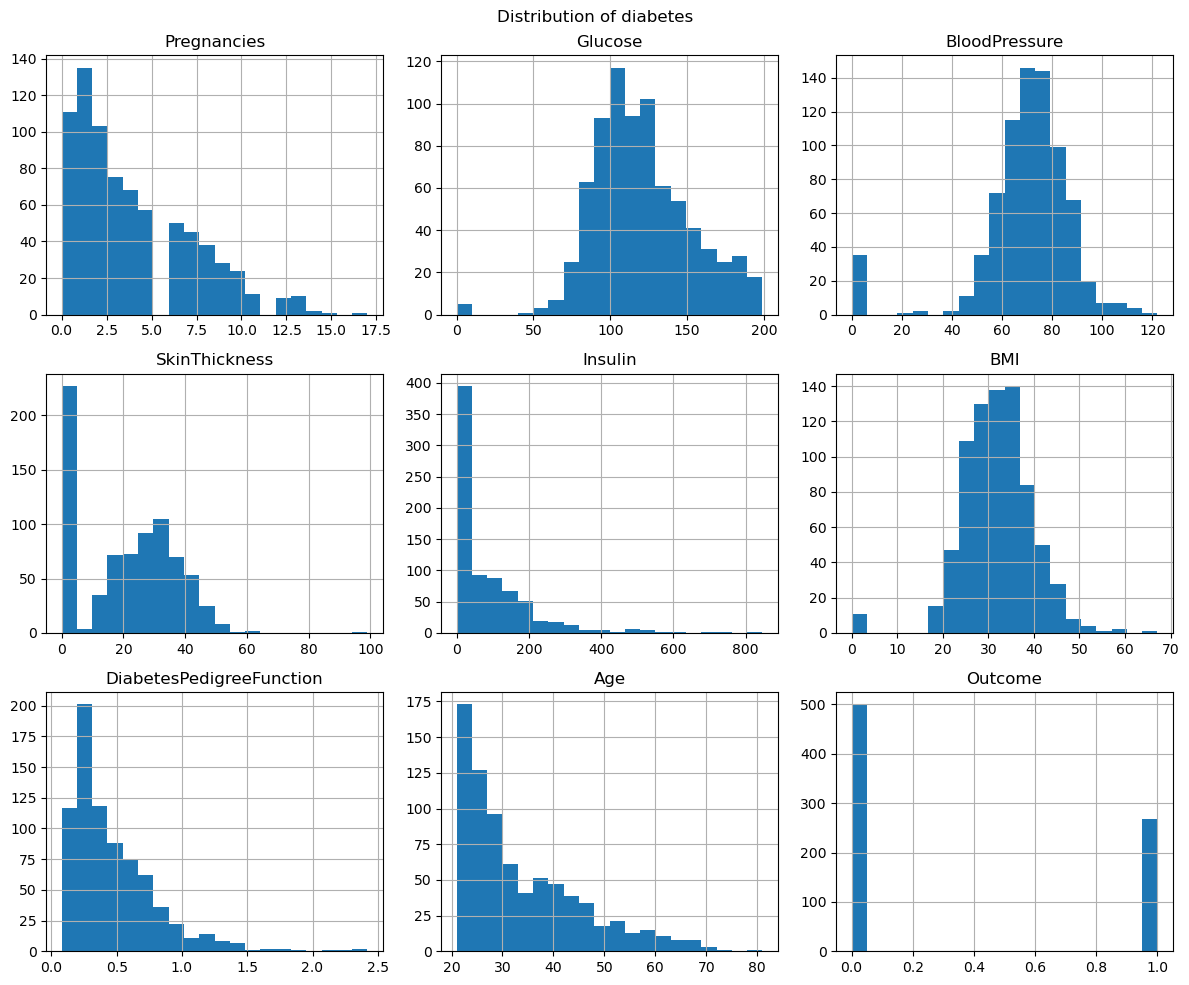

In [5]:
#histogram
df.hist(figsize=(12,10),bins=20)
plt.suptitle('Distribution of diabetes')
plt.tight_layout()
plt.show()

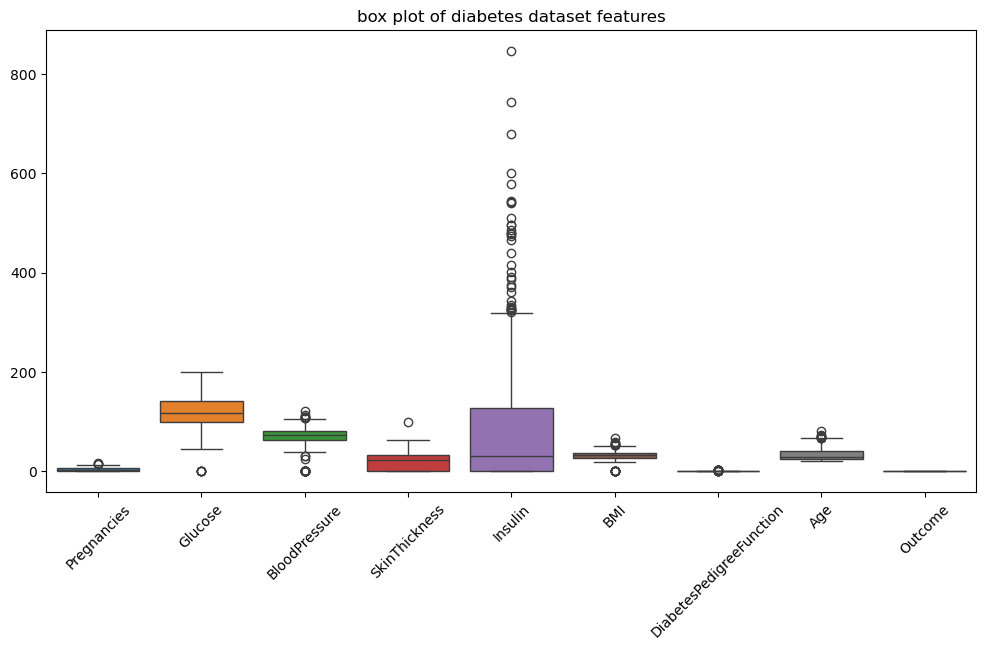

In [6]:
#Box Plot
plt.figure(figsize=(12,6))
sns.boxplot(data=df)
plt.title('box plot of diabetes dataset features')
plt.xticks(rotation=45)
plt.show()

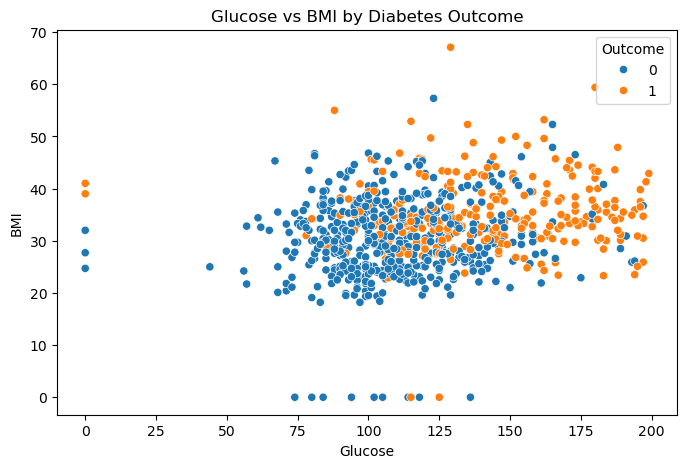

In [7]:
#scatter plot
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df,
    x="Glucose",
    y="BMI",
    hue="Outcome"
)
plt.title("Glucose vs BMI by Diabetes Outcome")
plt.xlabel("Glucose")
plt.ylabel("BMI")
plt.show()

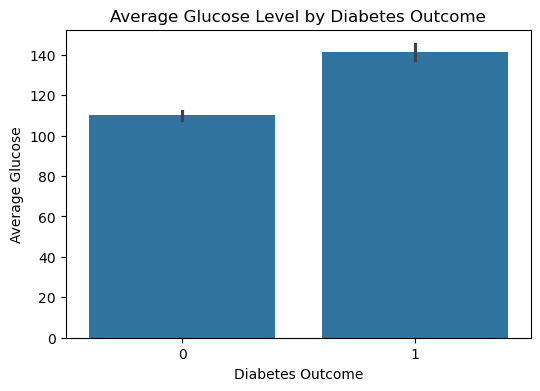

In [8]:
#Bar Plot
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x="Outcome",
    y="Glucose"
)
plt.title("Average Glucose Level by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Average Glucose")
plt.show()

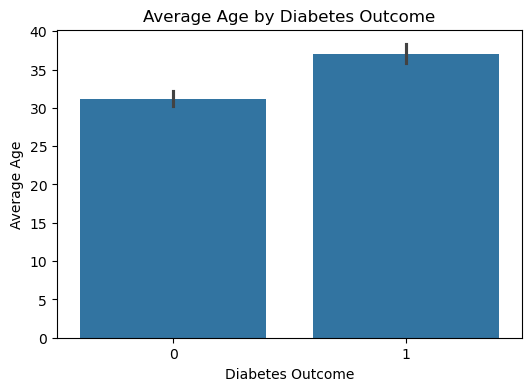

In [9]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=df,
    x="Outcome",
    y="Age"
)
plt.title("Average Age by Diabetes Outcome")
plt.xlabel("Diabetes Outcome")
plt.ylabel("Average Age")
plt.show()

**2.Data Preprocessing**

Identify missing values

In [10]:
import numpy as np
# Columns where 0 can represent missing values
columns_with_zero = [
    'Glucose',
    'BloodPressure',
    'SkinThickness',
    'Insulin',
    'BMI'
]
# Replace 0 with NaN
df[columns_with_zero] = df[columns_with_zero].replace(0, np.nan)


In [11]:
# Check missing values
df.isnull().sum()

Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64

In [12]:
# Fill missing values with median
for column in columns_with_zero:
    df[column] = df[column].fillna(df[column].median())
# Check again
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
df.dtypes

Pregnancies                   int64
Glucose                     float64
BloodPressure               float64
SkinThickness               float64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [14]:
# X = input features
# y = target variable
X = df.drop('Outcome', axis=1)
y = df['Outcome']
print("Features:")
print(X.head())
print("\nTarget:")
print(y.head())

Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  

Target:
0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64


train-test split

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (614, 8)
Testing data: (154, 8)


In [16]:
print("Missing values in X_train:")
print(X_train.isnull().sum())
print("\nMissing values in X_test:")
print(X_test.isnull().sum())

Missing values in X_train:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64

Missing values in X_test:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
dtype: int64


**3.Building Predictive Models**

In [17]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

Build LightGBM Model

In [18]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    verbosity=-1
)
# Train LightGBM
lgbm_model.fit(X_train, y_train)
# Prediction
y_pred_lgbm = lgbm_model.predict(X_test)

In [19]:
import sys
!{sys.executable} -m pip install lightgbm

In [20]:
#evaluate lightGBM
print("LightGBM Performance")
print("--------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm))
print("Precision:", precision_score(y_test, y_pred_lgbm))
print("Recall   :", recall_score(y_test, y_pred_lgbm))
print("F1 Score :", f1_score(y_test, y_pred_lgbm))

LightGBM Performance
--------------------
Accuracy : 0.7727272727272727
Precision: 0.6938775510204082
Recall   : 0.6296296296296297
F1 Score : 0.6601941747572816


In [21]:
print(classification_report(y_test,y_pred_lgbm))

              precision    recall  f1-score   support

           0       0.81      0.85      0.83       100
           1       0.69      0.63      0.66        54

    accuracy                           0.77       154
   macro avg       0.75      0.74      0.74       154
weighted avg       0.77      0.77      0.77       154



Build XGBoost Model

In [22]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    eval_metric='logloss'
)
# Train XGBoost
xgb_model.fit(X_train, y_train)
# Prediction
y_pred_xgb = xgb_model.predict(X_test)

In [23]:
print("XGBoost Performance")
print("-------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb))
print("Precision:", precision_score(y_test, y_pred_xgb))
print("Recall   :", recall_score(y_test, y_pred_xgb))
print("F1 Score :", f1_score(y_test, y_pred_xgb))

XGBoost Performance
-------------------
Accuracy : 0.7532467532467533
Precision: 0.6739130434782609
Recall   : 0.5740740740740741
F1 Score : 0.62


In [24]:
print(classification_report(y_test,y_pred_xgb))

              precision    recall  f1-score   support

           0       0.79      0.85      0.82       100
           1       0.67      0.57      0.62        54

    accuracy                           0.75       154
   macro avg       0.73      0.71      0.72       154
weighted avg       0.75      0.75      0.75       154



In [25]:
#cross validation for Lightgbm
from sklearn.model_selection import cross_val_score
lgbm_cv = cross_val_score(
    lgbm_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)
print("LightGBM CV Scores:", lgbm_cv)
print("Mean CV Accuracy:", lgbm_cv.mean())

LightGBM CV Scores: [0.77272727 0.75974026 0.74675325 0.80392157 0.74509804]
Mean CV Accuracy: 0.7656480774127832


In [26]:
#cross validation for xgb
xgb_cv = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring='accuracy'
)
print("XGBoost CV Scores:", xgb_cv)
print("Mean CV Accuracy:", xgb_cv.mean())

XGBoost CV Scores: [0.76623377 0.70779221 0.74025974 0.81045752 0.75163399]
Mean CV Accuracy: 0.7552754435107376


In [27]:
#Hyperparameter tuning of lightgbm
from sklearn.model_selection import GridSearchCV
lgbm_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
lgbm_grid = GridSearchCV(
    LGBMClassifier(random_state=42, verbosity=-1),
    lgbm_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
lgbm_grid.fit(X_train, y_train)
print("Best LightGBM Parameters:")
print(lgbm_grid.best_params_)
print("Best LightGBM Score:")
print(lgbm_grid.best_score_)

Best LightGBM Parameters:
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}
Best LightGBM Score:
0.7655471144875383


In [28]:
#hyper parameter of xgb
xgb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7]
}
xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
xgb_grid.fit(X_train, y_train)
print("Best XGBoost Parameters:")
print(xgb_grid.best_params_)
print("Best XGBoost Score:")
print(xgb_grid.best_score_)

Best XGBoost Parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best XGBoost Score:
0.7590030654404905


In [32]:
#evaluate tune model
best_lgbm = lgbm_grid.best_estimator_
best_xgb = xgb_grid.best_estimator_
y_pred_lgbm_tuned = best_lgbm.predict(X_test)
y_pred_xgb_tuned = best_xgb.predict(X_test)

In [33]:
print("Tuned LightGBM")
print("Accuracy :", accuracy_score(y_test, y_pred_lgbm_tuned))
print("Precision:", precision_score(y_test, y_pred_lgbm_tuned))
print("Recall   :", recall_score(y_test, y_pred_lgbm_tuned))
print("F1 Score :", f1_score(y_test, y_pred_lgbm_tuned))
print("\nTuned XGBoost")
print("Accuracy :", accuracy_score(y_test, y_pred_xgb_tuned))
print("Precision:", precision_score(y_test, y_pred_xgb_tuned))
print("Recall   :", recall_score(y_test, y_pred_xgb_tuned))
print("F1 Score :", f1_score(y_test, y_pred_xgb_tuned))

Tuned LightGBM
Accuracy : 0.7272727272727273
Precision: 0.65
Recall   : 0.48148148148148145
F1 Score : 0.5531914893617021

Tuned XGBoost
Accuracy : 0.7402597402597403
Precision: 0.6521739130434783
Recall   : 0.5555555555555556
F1 Score : 0.6


In [34]:
comparison = pd.DataFrame({
    'Model': ['LightGBM', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lgbm_tuned),
        accuracy_score(y_test, y_pred_xgb_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lgbm_tuned),
        precision_score(y_test, y_pred_xgb_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lgbm_tuned),
        recall_score(y_test, y_pred_xgb_tuned)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lgbm_tuned),
        f1_score(y_test, y_pred_xgb_tuned)
    ]
})
comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.727273,0.650000,0.481481,0.553191
1,XGBoost,0.740260,0.652174,0.555556,0.600000


Both LightGBM and XGBoost are trained and evaluated using accuracy, precision, recall, and F1-score. Five-fold cross-validation and GridSearchCV are then used to find better hyperparameters. Finally, the two tuned models can be compared using the comparison table

**4.Comparative Analysis**

In [35]:
# Calculate performance metrics
lgbm_results = {
    'Accuracy': accuracy_score(y_test, y_pred_lgbm),
    'Precision': precision_score(y_test, y_pred_lgbm),
    'Recall': recall_score(y_test, y_pred_lgbm),
    'F1 Score': f1_score(y_test, y_pred_lgbm)
}
xgb_results = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb),
    'Precision': precision_score(y_test, y_pred_xgb),
    'Recall': recall_score(y_test, y_pred_xgb),
    'F1 Score': f1_score(y_test, y_pred_xgb)
}
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'LightGBM': list(lgbm_results.values()),
    'XGBoost': list(xgb_results.values())
})
comparison

,Metric,LightGBM,XGBoost
0,Accuracy,0.772727,0.753247
1,Precision,0.693878,0.673913
2,Recall,0.629630,0.574074
3,F1 Score,0.660194,0.620000


Visualize the Comparision

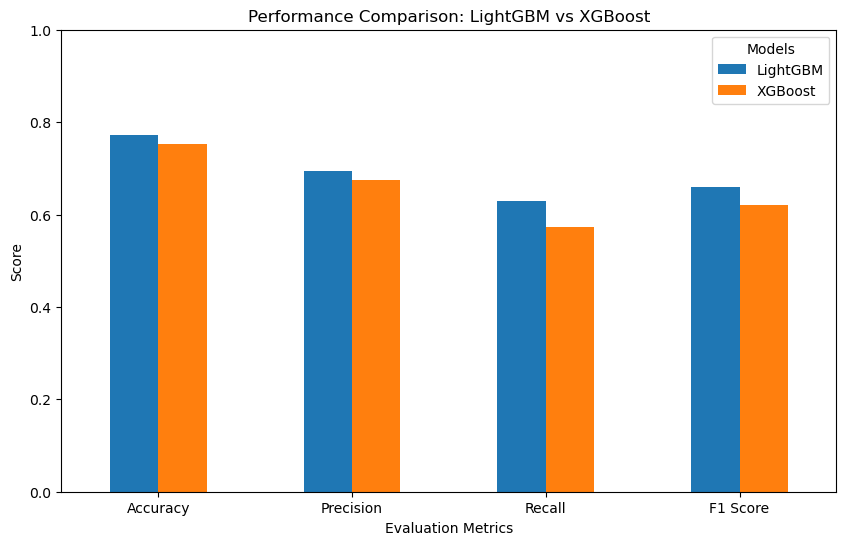

In [36]:
comparison.set_index('Metric').plot(
    kind='bar',
    figsize=(10, 6)
)
plt.title("Performance Comparison: LightGBM vs XGBoost")
plt.xlabel("Evaluation Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Models")
plt.show()

In [37]:
#Compare average performance
# Compare average performance
lgbm_average = (
    lgbm_results['Accuracy'] +
    lgbm_results['Precision'] +
    lgbm_results['Recall'] +
    lgbm_results['F1 Score']
) / 4
xgb_average = (
    xgb_results['Accuracy'] +
    xgb_results['Precision'] +
    xgb_results['Recall'] +
    xgb_results['F1 Score']
) / 4
print("LightGBM Average Score:", round(lgbm_average, 4))
print("XGBoost Average Score:", round(xgb_average, 4))
if lgbm_average > xgb_average:
    print("LightGBM performs better overall.")
elif xgb_average > lgbm_average:
    print("XGBoost performs better overall.")
else:
    print("Both models have similar overall performance.")

LightGBM Average Score: 0.6891
XGBoost Average Score: 0.6553
LightGBM performs better overall.


Interpretation:

LightGBM and XGBoost were compared using accuracy, precision, recall, and F1-score. The model with higher values across these metrics provides better classification performance. Accuracy shows the overall correctness of the model, precision shows how accurately positive diabetes predictions are made, recall shows how well the model identifies actual positive cases, and F1-score provides a balance between precision and recall.

Strengths and weaknesses:

LightGBM: Generally provides fast training and efficient performance, especially with larger datasets.

XGBoost: Provides strong predictive performance and has extensive options for controlling model complexity.

The better model for this dataset should be selected based on your actual test-set and cross-validation results rather than assuming one algorithm is always better.